# AccessAI - Prototipo de detección urbana

Este cuaderno demuestra la base del proyecto AccessAI:

1. Comprobar entorno y GPU.
2. Preparar el ROD-Dataset.
3. Filtrar y remapear las clases a 4 categorías.
4. Crear un `datasiltrado.yaml`.
5. Entrenar YOLO26n en la RTX 4060.
6. Cargar `best.pt`.
7. Evaluar el modelo en `test`.
8. Mostrar curvas de entrenamiento.
9. Ejecutar inferencia sobre una imagen y guardar el resultado.

### Clases finales

| ID | Clase |
|---:|---|
| 0 | `Obstaculo_Dinamico` |
| 1 | `Obstaculo_Fijo` |
| 2 | `Barrera_Arquitectonica` |
| 3 | `Infraestructura_Peatonal` |

> Importante: las etiquetas originales se conservan en `labels_originales` y nunca se usan como fuente para un segundo remapeo.


## 01. Entorno y GPU

Comprueba PyTorch, CUDA y la NVIDIA RTX 4060 antes de comenzar el entrenamiento.

In [1]:
# ============================================================
# ACCESSAI - 01. ENTORNO Y GPU
# ============================================================

from pathlib import Path
import os
import torch

print("=" * 70)
print("ACCESSAI - ENTORNO")
print("=" * 70)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"CUDA de PyTorch: {torch.version.cuda}")
print(f"HIP: {torch.version.hip}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

    props = torch.cuda.get_device_properties(0)

    print(
        f"Memoria GPU: "
        f"{props.total_memory / 1024**3:.2f} GB"
    )

    print(
        f"Compute capability: "
        f"{props.major}.{props.minor}"
    )

    print(
        f"Memoria reservada actualmente: "
        f"{torch.cuda.memory_reserved(0) / 1024**3:.2f} GB"
    )

    print(
        f"Memoria asignada actualmente: "
        f"{torch.cuda.memory_allocated(0) / 1024**3:.2f} GB"
    )
else:
    print("No hay GPU disponible.")

print("=" * 70)


ACCESSAI - ENTORNO
PyTorch: 2.14.0+cu126
CUDA disponible: True
CUDA de PyTorch: 12.6
HIP: None
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU count: 1
Memoria GPU: 8.00 GB
Compute capability: 8.9
Memoria reservada actualmente: 0.00 GB
Memoria asignada actualmente: 0.00 GB


## 02. Comprobar Ultralytics

In [2]:
# ============================================================
# ACCESSAI - 02. ULTRALYTICS
# ============================================================

import ultralytics

print("Ultralytics:", ultralytics.__version__)

!python -m pip show ultralytics


Ultralytics: 8.4.69
Name: ultralytics
Version: 8.4.69
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation, classification, and oriented object detection.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: c:\Users\Usuario\.conda\envs\proyecto_yolo\Lib\site-packages
Requires: matplotlib, numpy, nvidia-ml-py, opencv-python, pillow, polars, psutil, pyyaml, requests, scipy, torch, torchvision, ultralytics-thop
Required-by: 


## 03. Configuración del dataset

Se usa una ruta relativa al proyecto para que el notebook sea más portable en Windows.

In [3]:
# ============================================================
# ACCESSAI - 03. CONFIGURACIÓN DATASET
# ============================================================

from pathlib import Path
import os
import shutil
import yaml
from collections import Counter

ROOT = Path.cwd()

DATASET_PATH = ROOT / "DATA" / "ROD-Dataset" / "dataset"

yaml_original_path = DATASET_PATH / "data.yaml"
yaml_nuevo_path = DATASET_PATH / "data_filtrado.yaml"

print("Dataset:")
print(DATASET_PATH)

print("\nExiste dataset:", DATASET_PATH.exists())
print("Existe data.yaml:", yaml_original_path.exists())

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No existe el dataset:\n{DATASET_PATH}"
    )

if not yaml_original_path.exists():
    raise FileNotFoundError(
        f"No existe:\n{yaml_original_path}"
    )


Dataset:
c:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\DATA\ROD-Dataset\dataset

Existe dataset: True
Existe data.yaml: True


## 04. Mapeo de clases del ROD-Dataset

In [4]:
# ============================================================
# ACCESSAI - 04. MAPEO DE CLASES
# ============================================================

MAPEO_CLASES = {
    0: 0,    # Bike -> Obstaculo_Dinamico
    2: 0,    # Car -> Obstaculo_Dinamico
    8: 0,    # Motorcycle -> Obstaculo_Dinamico
    15: 0,   # Truck -> Obstaculo_Dinamico
    16: 0,   # Bus -> Obstaculo_Dinamico

    9: 1,    # Dustbin -> Obstaculo_Fijo
    17: 1,   # Bench -> Obstaculo_Fijo
    18: 1,   # Traffic Cone -> Obstaculo_Fijo
    19: 1,   # Fire hydrant -> Obstaculo_Fijo
    20: 1,   # Teraffic Barrel -> Obstaculo_Fijo
    21: 1,   # Plant Pot -> Obstaculo_Fijo
    22: 1,   # Electrical Box -> Obstaculo_Fijo
    23: 1,   # Chair -> Obstaculo_Fijo
    24: 1,   # Bicycle Rack -> Obstaculo_Fijo

    4: 2,    # Stairs -> Barrera_Arquitectonica

    11: 3,   # Manhole -> Infraestructura_Peatonal
    14: 3    # Pedestrian crosswalk -> Infraestructura_Peatonal
}

NUEVOS_NOMBRES = [
    "Obstaculo_Dinamico",
    "Obstaculo_Fijo",
    "Barrera_Arquitectonica",
    "Infraestructura_Peatonal"
]

NUM_CLASSES = len(NUEVOS_NOMBRES)

print("Clases finales:")
for idx, nombre in enumerate(NUEVOS_NOMBRES):
    print(f"  {idx}: {nombre}")

print(f"\nNúmero de clases: {NUM_CLASSES}")


Clases finales:
  0: Obstaculo_Dinamico
  1: Obstaculo_Fijo
  2: Barrera_Arquitectonica
  3: Infraestructura_Peatonal

Número de clases: 4


## 05. Crear `data_filtrado.yaml`

In [5]:
# ============================================================
# ACCESSAI - 05. NUEVO DATA.YAML
# ============================================================

with open(yaml_original_path, "r", encoding="utf-8") as f:
    config_original = yaml.safe_load(f)

print("Contenido original:")
print(config_original)

config_nueva = {
    "path": str(DATASET_PATH.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": NUM_CLASSES,
    "names": NUEVOS_NOMBRES
}

with open(yaml_nuevo_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        config_nueva,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("\n✅ Nuevo YAML creado:")
print(yaml_nuevo_path)

print("\nContenido:")
with open(yaml_nuevo_path, "r", encoding="utf-8") as f:
    print(f.read())


Contenido original:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 25, 'names': ['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree', 'Guard rail', 'Pedestrian crosswalk', 'Truck', 'Bus', 'Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']}

✅ Nuevo YAML creado:
c:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\DATA\ROD-Dataset\dataset\data_filtrado.yaml

Contenido:
path: C:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA
  SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\DATA\ROD-Dataset\dataset
train: train/images
val: valid/images
test: test/images
nc: 4
names:
- Obstaculo_Dinamico
- Obstaculo_Fijo
- Barrera_Arquitectonica
- Infraestructura_Peatonal



## 06. Preparar etiquetas

La transformación es idempotente: siempre toma como fuente `labels_originales`, evitando remapear por segunda vez las etiquetas ya transformadas.

In [6]:
# ============================================================
# ACCESSAI - 06. PREPARAR ETIQUETAS
# ============================================================

def preparar_etiquetas(split):
    """
    Conserva las etiquetas originales y genera las etiquetas
    filtradas/remapeadas de forma segura.

    La transformación es idempotente:
    ejecutar esta función varias veces NO remapea etiquetas
    que ya fueron transformadas.
    """

    split_dir = DATASET_PATH / split

    labels_dir = split_dir / "labels"
    labels_originales_dir = split_dir / "labels_originales"

    if not split_dir.exists():
        raise FileNotFoundError(
            f"No existe el split:\n{split_dir}"
        )

    if labels_originales_dir.exists():
        source_dir = labels_originales_dir
        print(f"↪ {split}: usando labels_originales como fuente")
    elif labels_dir.exists():
        print(f"↪ {split}: guardando labels originales")
        labels_dir.rename(labels_originales_dir)
        source_dir = labels_originales_dir
    else:
        raise FileNotFoundError(
            f"No existe la carpeta labels en:\n{split_dir}"
        )

    labels_filtradas_dir = split_dir / "labels_filtradas"

    if labels_filtradas_dir.exists():
        shutil.rmtree(labels_filtradas_dir)

    labels_filtradas_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    clases_originales = Counter()
    clases_nuevas = Counter()
    clases_descartadas = Counter()

    archivos_procesados = 0

    for archivo in sorted(source_dir.glob("*.txt")):
        archivos_procesados += 1

        ruta_salida = labels_filtradas_dir / archivo.name
        nuevas_lineas = []

        with open(archivo, "r", encoding="utf-8") as f:
            for linea in f:
                partes = linea.strip().split()

                if not partes:
                    continue

                try:
                    clase_original = int(partes[0])
                except ValueError:
                    print(
                        f"⚠️ Clase inválida en {archivo.name}: "
                        f"{partes[0]}"
                    )
                    continue

                clases_originales[clase_original] += 1

                if clase_original not in MAPEO_CLASES:
                    clases_descartadas[clase_original] += 1
                    continue

                clase_nueva = MAPEO_CLASES[clase_original]
                partes[0] = str(clase_nueva)

                nuevas_lineas.append(
                    " ".join(partes) + "\n"
                )

                clases_nuevas[clase_nueva] += 1

        with open(ruta_salida, "w", encoding="utf-8") as f:
            f.writelines(nuevas_lineas)

    if labels_dir.exists():
        shutil.rmtree(labels_dir)

    labels_filtradas_dir.rename(labels_dir)

    print("\n" + "-" * 70)
    print(f"Split: {split}")
    print("-" * 70)
    print(f"Archivos procesados: {archivos_procesados}")

    print("\nClases originales encontradas:")
    for clase, cantidad in sorted(clases_originales.items()):
        print(f"  {clase}: {cantidad}")

    print("\nClases finales:")
    for clase, nombre in enumerate(NUEVOS_NOMBRES):
        print(f"  {clase} - {nombre}: {clases_nuevas[clase]}")

    print("\nClases descartadas:")
    if clases_descartadas:
        for clase, cantidad in sorted(clases_descartadas.items()):
            print(f"  {clase}: {cantidad}")
    else:
        print("  Ninguna")

    print(f"\n✅ {split} preparado correctamente.")


for split in ["train", "valid", "test"]:
    preparar_etiquetas(split)


↪ train: usando labels_originales como fuente

----------------------------------------------------------------------
Split: train
----------------------------------------------------------------------
Archivos procesados: 19186

Clases originales encontradas:
  0: 323
  1: 886
  2: 4328
  3: 7609
  4: 1125
  5: 689
  6: 491
  7: 561
  8: 888
  9: 1351
  10: 633
  11: 1779
  12: 1632
  13: 1385
  14: 1875
  15: 621
  16: 1009
  17: 706
  18: 678
  19: 205
  20: 540
  21: 560
  22: 450
  23: 1757
  24: 170

Clases finales:
  0 - Obstaculo_Dinamico: 7169
  1 - Obstaculo_Fijo: 6417
  2 - Barrera_Arquitectonica: 1125
  3 - Infraestructura_Peatonal: 3654

Clases descartadas:
  1: 886
  3: 7609
  5: 689
  6: 491
  7: 561
  10: 633
  12: 1632
  13: 1385

✅ train preparado correctamente.
↪ valid: usando labels_originales como fuente

----------------------------------------------------------------------
Split: valid
----------------------------------------------------------------------
Archivo

## 07. Comprobar estructura del dataset

In [7]:
# ============================================================
# ACCESSAI - 07. COMPROBACIÓN DATASET
# ============================================================

for split in ["train", "valid", "test"]:
    split_dir = DATASET_PATH / split

    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"
    originals_dir = split_dir / "labels_originales"

    image_count = len(list(images_dir.glob("*")))
    label_count = len(list(labels_dir.glob("*.txt")))
    original_count = len(list(originals_dir.glob("*.txt")))

    print("=" * 70)
    print(split)
    print(f"Imágenes:           {image_count}")
    print(f"Labels activas:     {label_count}")
    print(f"Labels originales:  {original_count}")


train
Imágenes:           19186
Labels activas:     19186
Labels originales:  19186
valid
Imágenes:           3511
Labels activas:     3511
Labels originales:  3511
test
Imágenes:           1629
Labels activas:     1629
Labels originales:  1629


## 08. Entrenamiento YOLO26n

Configuración pensada para la RTX 4060 Laptop de 8 GB:

- `batch=-1`: AutoBatch.
- `cache="ram"`: reduce la lectura repetitiva de disco si hay RAM suficiente.
- `amp=True`: mixed precision.
- `workers=4`: valor conservador para Windows.
- `close_mosaic=10`: desactiva Mosaic al final del entrenamiento.
- `patience=8`: early stopping.


In [8]:
# ============================================================
# ACCESSAI - 08. ENTRENAMIENTO
# ============================================================

import torch
from ultralytics import YOLO

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA no está disponible. El entrenamiento no se iniciará."
    )

device = 0

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("GPU:", torch.cuda.get_device_name(device))

MODEL_PATH = ROOT / "yolo26n.pt"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{MODEL_PATH}"
    )

model = YOLO(str(MODEL_PATH))

print("\nModelo cargado:")
print(MODEL_PATH)

results = model.train(
    data=str(yaml_nuevo_path),

    epochs=35,
    patience=8,

    imgsz=640,
    batch=32,

    device=device,
    workers=4,

    cache="ram",
    amp=True,

    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,

    augment=True,
    mosaic=1.0,
    close_mosaic=10,
    mixup=0.0,

    cls=1.0,

    val=True,

    save=True,
    save_period=-1,
    plots=True,

    seed=42,

    project="AccessAI_Proto3",
    name="yolo26n_4clases",
    exist_ok=False
)

print("\n✅ ENTRENAMIENTO TERMINADO")
print("Directorio:", results.save_dir)


GPU: NVIDIA GeForce RTX 4060 Laptop GPU

Modelo cargado:
c:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\yolo26n.pt
New https://pypi.org/project/ultralytics/8.4.160 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.69  Python-3.11.16 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:\III DIPLOMA DE EXTENSIN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\DATA\ROD-Dataset\dataset\data_filtrado.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, e

## 09. Cargar el `best.pt` entrenado

A partir de aquí usamos el modelo entrenado de AccessAI, no el `yolo26n.pt` preentrenado.

In [9]:
# ============================================================
# ACCESSAI - 09. CARGAR BEST.PT
# ============================================================

from pathlib import Path
from ultralytics import YOLO

RUN_DIR = Path(results.save_dir)
BEST_MODEL = RUN_DIR / "weights" / "best.pt"

print("RUN_DIR:")
print(RUN_DIR)

print("\nBEST MODEL:")
print(BEST_MODEL)

print("\nExiste:", BEST_MODEL.exists())

if not BEST_MODEL.exists():
    raise FileNotFoundError(
        f"No se encontró best.pt en:\n{BEST_MODEL}"
    )

trained_model = YOLO(str(BEST_MODEL))

print("\n✅ Modelo AccessAI cargado")

print("\nClases:")
for idx, name in trained_model.names.items():
    print(idx, "->", name)


RUN_DIR:
C:\Users\Usuario\runs\detect\AccessAI_Proto3\yolo26n_4clases

BEST MODEL:
C:\Users\Usuario\runs\detect\AccessAI_Proto3\yolo26n_4clases\weights\best.pt

Existe: True

✅ Modelo AccessAI cargado

Clases:
0 -> Obstaculo_Dinamico
1 -> Obstaculo_Fijo
2 -> Barrera_Arquitectonica
3 -> Infraestructura_Peatonal


## 10. Evaluación en el conjunto `test`

In [10]:
# ============================================================
# ACCESSAI - 10. EVALUACIÓN TEST
# ============================================================

metrics = trained_model.val(
    data=str(yaml_nuevo_path),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("\n" + "=" * 70)
print("MÉTRICAS TEST")
print("=" * 70)

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")


Ultralytics 8.4.69  Python-3.11.16 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 19.315.0 MB/s, size: 71.9 KB)
val: Scanning C:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\DATA\ROD-Dataset\dataset\test\labels... 1629 images, 452 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1629/1629 1.5Kit/s 1.1s0.1s
val: New cache created: C:\III DIPLOMA DE EXTENSIN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\DATA\ROD-Dataset\dataset\test\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 285, len(boxes) = 1566. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
         

## 11. Cargar `results.csv` y visualizar curvas

In [11]:
# ============================================================
# ACCESSAI - 11. CARGAR MÉTRICAS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUN_DIR / "results.csv"

print("CSV:")
print(results_csv)

if not results_csv.exists():
    raise FileNotFoundError(
        f"No existe:\n{results_csv}"
    )

df = pd.read_csv(results_csv)

print("\nColumnas:")
print(df.columns.tolist())


CSV:
C:\Users\Usuario\runs\detect\AccessAI_Proto3\yolo26n_4clases\results.csv

Columnas:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


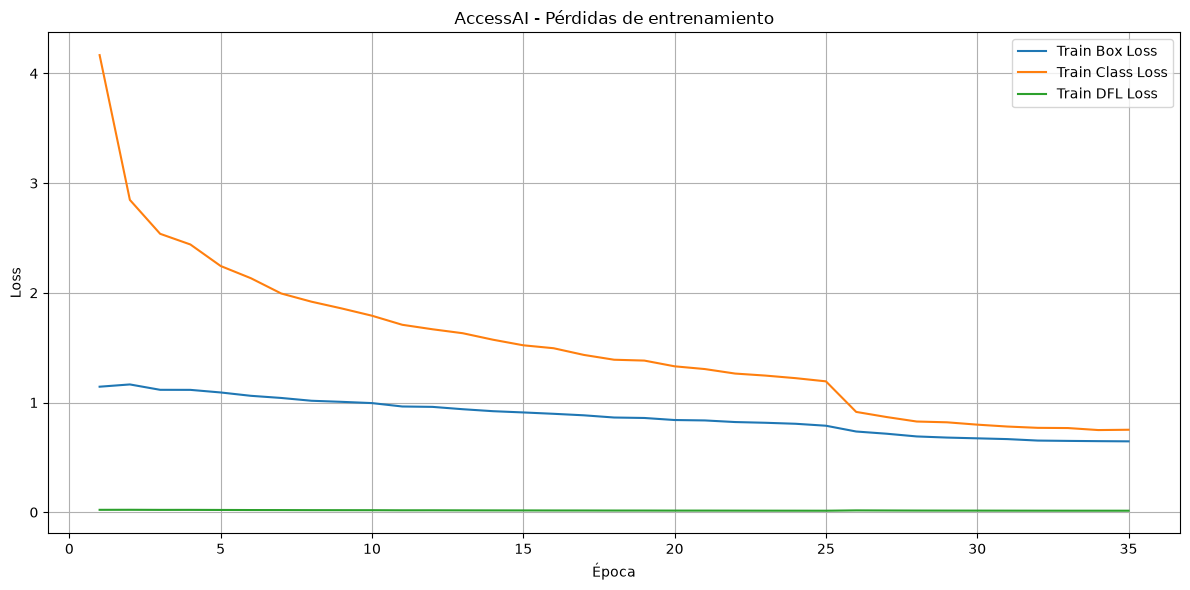

In [13]:
# ============================================================
# ACCESSAI - 11.1 LOSS
# ============================================================
%matplotlib inline
plt.figure(figsize=(12, 6))

plt.plot(
    df["epoch"],
    df["train/box_loss"],
    label="Train Box Loss"
)

plt.plot(
    df["epoch"],
    df["train/cls_loss"],
    label="Train Class Loss"
)

plt.plot(
    df["epoch"],
    df["train/dfl_loss"],
    label="Train DFL Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("AccessAI - Pérdidas de entrenamiento")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


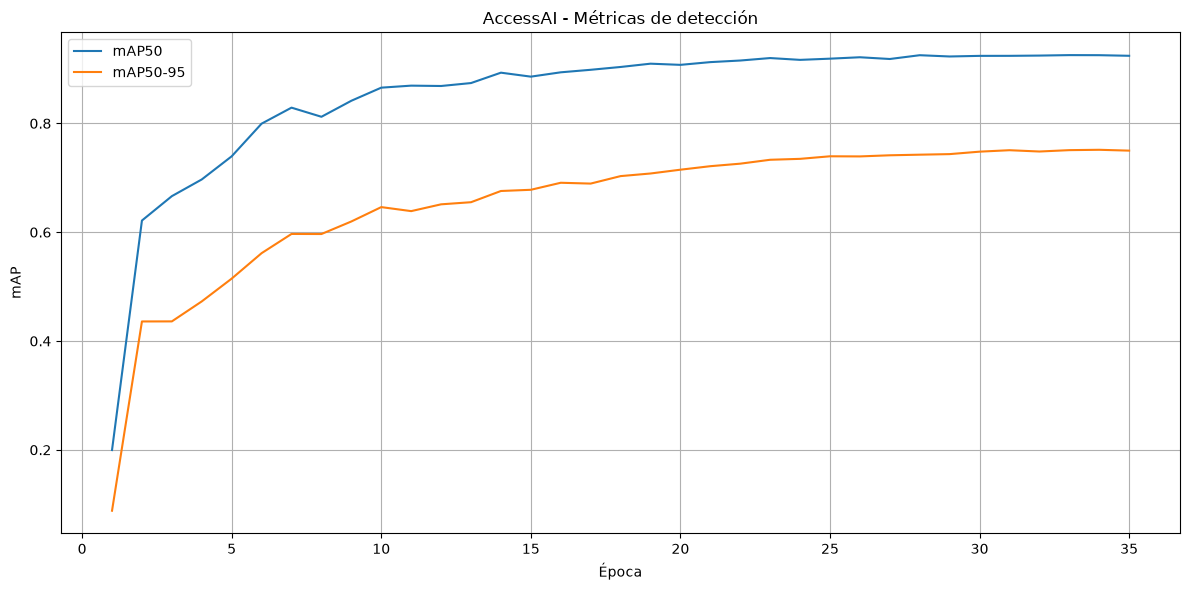

In [14]:
# ============================================================
# ACCESSAI - 11.2 mAP
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP50"
)

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

plt.xlabel("Época")
plt.ylabel("mAP")
plt.title("AccessAI - Métricas de detección")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


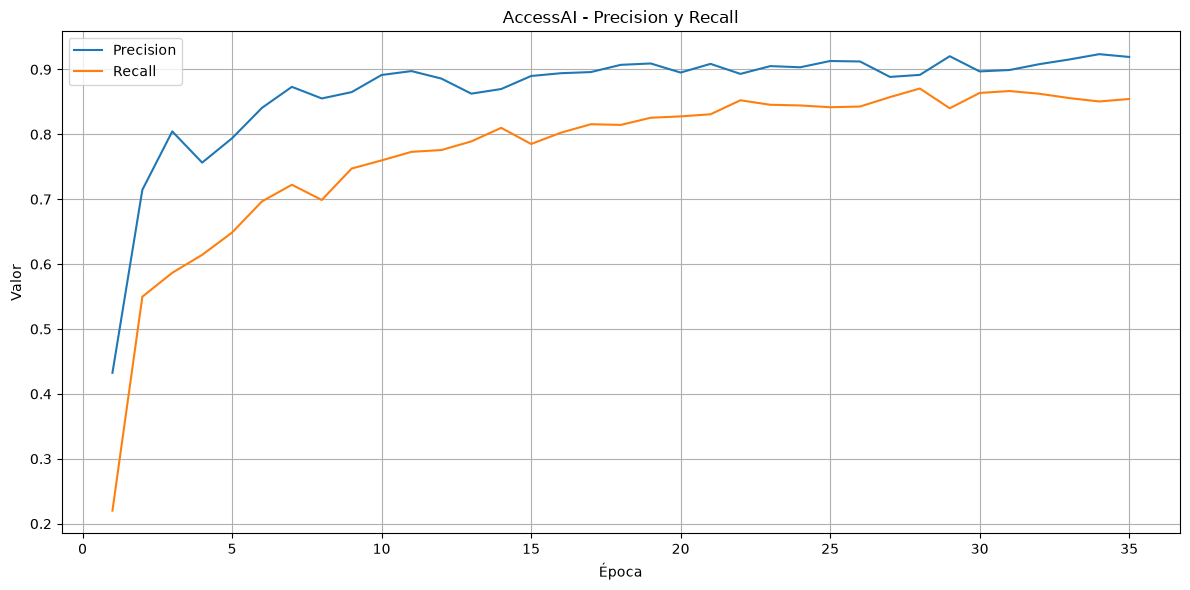

In [15]:
# ============================================================
# ACCESSAI - 11.3 PRECISION / RECALL
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["epoch"],
    df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    df["epoch"],
    df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Época")
plt.ylabel("Valor")
plt.title("AccessAI - Precision y Recall")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## 12. Seleccionar una imagen de prueba

El notebook busca una de varias rutas habituales dentro del proyecto.

In [16]:
# ============================================================
# ACCESSAI - 12. SELECCIONAR IMAGEN
# ============================================================

from pathlib import Path
import cv2
import matplotlib.pyplot as plt

ROOT = Path.cwd()

sample_candidates = [
    ROOT / "tests" / "imgs" / "image.png",
    ROOT / "tests" / "imgs" / "IMG_20170311_205902.jpg",
    ROOT / "DATA" / "ROD-Dataset" / "dataset" / "test" / "images" / "IMG_19187.jpg",
]

image_path = next(
    (p for p in sample_candidates if p.exists()),
    None
)

if image_path is None:
    raise FileNotFoundError(
        "No se encontró ninguna imagen de prueba."
    )

print("Imagen:")
print(image_path)


Imagen:
c:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\tests\imgs\image.png


## 13. Inferencia

In [17]:
# ============================================================
# ACCESSAI - 13. INFERENCIA
# ============================================================

results_predict = trained_model.predict(
    source=str(image_path),
    conf=0.25,
    imgsz=640,
    device=0,
    verbose=False
)

result = results_predict[0]

print(
    f"\nDetecciones encontradas: "
    f"{len(result.boxes)}"
)

if result.boxes is not None and len(result.boxes) > 0:

    for idx, box in enumerate(
        result.boxes,
        start=1
    ):
        cls_id = int(box.cls[0])
        cls_name = trained_model.names[cls_id]
        confidence = float(box.conf[0])
        coords = box.xyxy[0].tolist()

        print(
            f"[{idx}] "
            f"{cls_name} | "
            f"conf={confidence:.3f} | "
            f"bbox={coords}"
        )
else:
    print(
        "No se detectaron objetos con conf=0.25."
    )



Detecciones encontradas: 1
[1] Infraestructura_Peatonal | conf=0.817 | bbox=[0.0, 246.73526000976562, 186.3348388671875, 322.7213134765625]


## 14. Guardar y mostrar la imagen anotada

✅ Imagen guardada en:
c:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\resultados\accessai_resultado.jpg


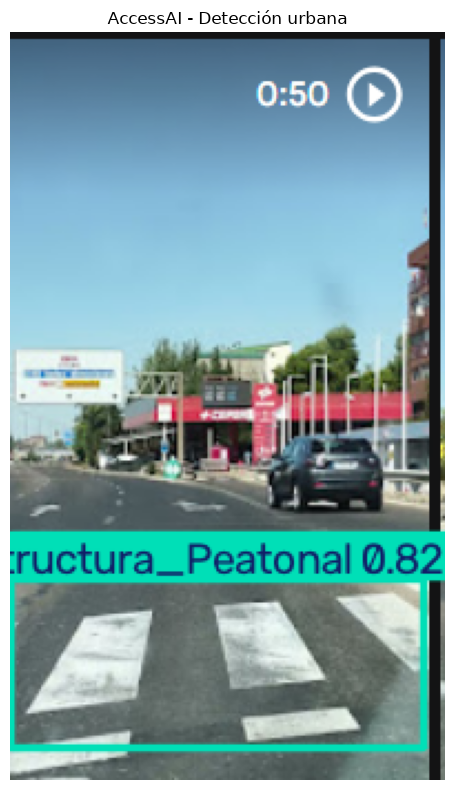

In [18]:
# ============================================================
# ACCESSAI - 14. RESULTADO
# ============================================================

output_dir = ROOT / "resultados"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "accessai_resultado.jpg"
)

annotated = result.plot()

ok = cv2.imwrite(
    str(output_path),
    annotated
)

if not ok:
    raise IOError(
        f"No se pudo guardar la imagen en:\n{output_path}"
    )

print("✅ Imagen guardada en:")
print(output_path)

annotated_rgb = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("AccessAI - Detección urbana")
plt.tight_layout()
plt.show()


## 15. Resumen del experimento

Al terminar, conserva al menos:

- `best.pt`
- `results.csv`
- `confusion_matrix.png`
- `results.png`
- imagen anotada de inferencia
- valores de `mAP50`, `mAP50-95`, Precision y Recall

El objetivo de este prototipo es medir la capacidad del modelo para detectar las cuatro categorías seleccionadas del ROD-Dataset.


In [ ]:
# [markdown]
#  AccessAI - Prototipo de detección urbana
#
# Este cuaderno demuestra la base del proyecto AccessAI:
#
# 1. Comprobar entorno y GPU.
# 2. Preparar el ROD-Dataset.
# 3. Filtrar y remapear las clases a 4 categorías.
# 4. Crear un `data_filtrado.yaml`.
# 5. Entrenar YOLO26n en la RTX 4060.
# 6. Cargar `best.pt`.
# 7. Evaluar el modelo en `test`.
# 8. Mostrar curvas de entrenamiento.
# 9. Ejecutar inferencia sobre una imagen y guardar el resultado.
#
# ## Clases finales
#
# | ID | Clase |
# |---:|---|
# | 0 | `Obstaculo_Dinamico` |
# | 1 | `Obstaculo_Fijo` |
# | 2 | `Barrera_Arquitectonica` |
# | 3 | `Infraestructura_Peatonal` |
#
# > Importante: las etiquetas originales se conservan en `labels_originales` y nunca se usan como fuente para un segundo remapeo.
#

# [markdown]
# # 01. Entorno y GPU
#
# Comprueba PyTorch, CUDA y la NVIDIA RTX 4060 antes de comenzar el entrenamiento.

# ============================================================
# ACCESSAI - 01. ENTORNO Y GPU
# ============================================================

from pathlib import Path
import os
import torch

print("=" * 70)
print("ACCESSAI - ENTORNO")
print("=" * 70)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"CUDA de PyTorch: {torch.version.cuda}")
print(f"HIP: {torch.version.hip}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

    props = torch.cuda.get_device_properties(0)

    print(
        f"Memoria GPU: "
        f"{props.total_memory / 1024**3:.2f} GB"
    )

    print(
        f"Compute capability: "
        f"{props.major}.{props.minor}"
    )

    print(
        f"Memoria reservada actualmente: "
        f"{torch.cuda.memory_reserved(0) / 1024**3:.2f} GB"
    )

    print(
        f"Memoria asignada actualmente: "
        f"{torch.cuda.memory_allocated(0) / 1024**3:.2f} GB"
    )
else:
    print("No hay GPU disponible.")

print("=" * 70)


# [markdown]
# # 02. Comprobar Ultralytics

# ============================================================
# ACCESSAI - 02. ULTRALYTICS
# ============================================================

import ultralytics

print("Ultralytics:", ultralytics.__version__)

!python -m pip show ultralytics


# [markdown]
# # 03. Configuración del dataset
#
# Se usa una ruta relativa al proyecto para que el notebook sea más portable en Windows.

# ============================================================
# ACCESSAI - 03. CONFIGURACIÓN DATASET
# ============================================================

from pathlib import Path
import os
import shutil
import yaml
from collections import Counter

ROOT = Path.cwd()

DATASET_PATH = ROOT / "DATA" / "ROD-Dataset" / "dataset"

yaml_original_path = DATASET_PATH / "data.yaml"
yaml_nuevo_path = DATASET_PATH / "data_filtrado.yaml"

print("Dataset:")
print(DATASET_PATH)

print("\nExiste dataset:", DATASET_PATH.exists())
print("Existe data.yaml:", yaml_original_path.exists())

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"edNo existe el dataset:\n{DATASET_PATH}"
    )

if not yaml_original_path.exists():
    raise FileNotFoundError(
        f"No existe:\n{yaml_original_path}"
    )


# [markdown]
# # 04. Mapeo de clases del ROD-Dataset

# ============================================================
# ACCESSAI - 04. MAPEO DE CLASES
# ============================================================

MAPEO_CLASES = {
    0: 0,    # Bike -> Obstaculo_Dinamico
    2: 0,    # Car -> Obstaculo_Dinamico
    8: 0,    # Motorcycle -> Obstaculo_Dinamico
    15: 0,   # Truck -> Obstaculo_Dinamico
    16: 0,   # Bus -> Obstaculo_Dinamico

    9: 1,    # Dustbin -> Obstaculo_Fijo
    17: 1,   # Bench -> Obstaculo_Fijo
    18: 1,   # Traffic Cone -> Obstaculo_Fijo
    19: 1,   # Fire hydrant -> Obstaculo_Fijo
    20: 1,   # Teraffic Barrel -> Obstaculo_Fijo
    21: 1,   # Plant Pot -> Obstaculo_Fijo
    22: 1,   # Electrical Box -> Obstaculo_Fijo
    23: 1,   # Chair -> Obstaculo_Fijo
    24: 1,   # Bicycle Rack -> Obstaculo_Fijo

    4: 2,    # Stairs -> Barrera_Arquitectonica

    11: 3,   # Manhole -> Infraestructura_Peatonal
    14: 3    # Pedestrian crosswalk -> Infraestructura_Peatonal
}

NUEVOS_NOMBRES = [
    "Obstaculo_Dinamico",
    "Obstaculo_Fijo",
    "Barrera_Arquitectonica",
    "Infraestructura_Peatonal"
]

NUM_CLASSES = len(NUEVOS_NOMBRES)

print("Clases finales:")
for idx, nombre in enumerate(NUEVOS_NOMBRES):
    print(f"  {idx}: {nombre}")

print(f"\nNúmero de clases: {NUM_CLASSES}")


# [markdown]
# # 05. Crear `data_filtrado.yaml`

# ============================================================
# ACCESSAI - 05. NUEVO DATA.YAML
# ============================================================

with open(yaml_original_path, "r", encoding="utf-8") as f:
    config_original = yaml.safe_load(f)

print("Contenido original:")
print(config_original)

config_nueva = {
    "path": str(DATASET_PATH.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": NUM_CLASSES,
    "names": NUEVOS_NOMBRES
}

with open(yaml_nuevo_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        config_nueva,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("\n✅ Nuevo YAML creado:")
print(yaml_nuevo_path)

print("\nContenido:")
with open(yaml_nuevo_path, "r", encoding="utf-8") as f:
    print(f.read())


# [markdown]
# # 06. Preparar etiquetas
#
# La transformación es idempotente: siempre toma como fuente `labels_originales`, evitando remapear por segunda vez las etiquetas ya transformadas.

# ============================================================
# ACCESSAI - 06. PREPARAR ETIQUETAS
# ============================================================

def preparar_etiquetas(split):
    """
    Conserva las etiquetas originales y genera las etiquetas
    filtradas/remapeadas de forma segura.

    La transformación es idempotente:
    ejecutar esta función varias veces NO remapea etiquetas
    que ya fueron transformadas.
    """

    split_dir = DATASET_PATH / split

    labels_dir = split_dir / "labels"
    labels_originales_dir = split_dir / "labels_originales"

    if not split_dir.exists():
        raise FileNotFoundError(
            f"No existe el split:\n{split_dir}"
        )

    if labels_originales_dir.exists():
        source_dir = labels_originales_dir
        print(f"↪ {split}: usando labels_originales como fuente")
    elif labels_dir.exists():
        print(f"↪ {split}: guardando labels originales")
        labels_dir.rename(labels_originales_dir)
        source_dir = labels_originales_dir
    else:
        raise FileNotFoundError(
            f"No existe la carpeta labels en:\n{split_dir}"
        )

    labels_filtradas_dir = split_dir / "labels_filtradas"

    if labels_filtradas_dir.exists():
        shutil.rmtree(labels_filtradas_dir)

    labels_filtradas_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    clases_originales = Counter()
    clases_nuevas = Counter()
    clases_descartadas = Counter()

    archivos_procesados = 0

    for archivo in sorted(source_dir.glob("*.txt")):
        archivos_procesados += 1

        ruta_salida = labels_filtradas_dir / archivo.name
        nuevas_lineas = []

        with open(archivo, "r", encoding="utf-8") as f:
            for linea in f:
                partes = linea.strip().split()

                if not partes:
                    continue

                try:
                    clase_original = int(partes[0])
                except ValueError:
                    print(
                        f"⚠️ Clase inválida en {archivo.name}: "
                        f"{partes[0]}"
                    )
                    continue

                clases_originales[clase_original] += 1

                if clase_original not in MAPEO_CLASES:
                    clases_descartadas[clase_original] += 1
                    continue

                clase_nueva = MAPEO_CLASES[clase_original]
                partes[0] = str(clase_nueva)

                nuevas_lineas.append(
                    " ".join(partes) + "\n"
                )

                clases_nuevas[clase_nueva] += 1

        with open(ruta_salida, "w", encoding="utf-8") as f:
            f.writelines(nuevas_lineas)

    if labels_dir.exists():
        shutil.rmtree(labels_dir)

    labels_filtradas_dir.rename(labels_dir)

    print("\n" + "-" * 70)
    print(f"Split: {split}")
    print("-" * 70)
    print(f"Archivos procesados: {archivos_procesados}")

    print("\nClases originales encontradas:")
    for clase, cantidad in sorted(clases_originales.items()):
        print(f"  {clase}: {cantidad}")

    print("\nClases finales:")
    for clase, nombre in enumerate(NUEVOS_NOMBRES):
        print(f"  {clase} - {nombre}: {clases_nuevas[clase]}")

    print("\nClases descartadas:")
    if clases_descartadas:
        for clase, cantidad in sorted(clases_descartadas.items()):
            print(f"  {clase}: {cantidad}")
    else:
        print("  Ninguna")

    print(f"\n✅ {split} preparado correctamente.")


for split in ["train", "valid", "test"]:
    preparar_etiquetas(split)


# [markdown]
# # 07. Comprobar estructura del dataset

# ============================================================
# ACCESSAI - 07. COMPROBACIÓN DATASET
# ============================================================

for split in ["train", "valid", "test"]:
    split_dir = DATASET_PATH / split

    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"
    originals_dir = split_dir / "labels_originales"

    image_count = len(list(images_dir.glob("*")))
    label_count = len(list(labels_dir.glob("*.txt")))
    original_count = len(list(originals_dir.glob("*.txt")))

    print("=" * 70)
    print(split)
    print(f"Imágenes:           {image_count}")
    print(f"Labels activas:     {label_count}")
    print(f"Labels originales:  {original_count}")


# [markdown]
# # 08. Entrenamiento YOLO26n
#
# Configuración pensada para la RTX 4060 Laptop de 8 GB:
#
# - `batch=-1`: AutoBatch.
# - `cache="ram"`: reduce la lectura repetitiva de disco si hay RAM suficiente.
# - `amp=True`: mixed precision.
# - `workers=4`: valor conservador para Windows.
# - `close_mosaic=10`: desactiva Mosaic al final del entrenamiento.
# - `patience=8`: early stopping.
#

# ============================================================
# ACCESSAI - 08. ENTRENAMIENTO
# ============================================================

import torch
from ultralytics import YOLO

if torch.cuda.is_available():
    device = 0
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("GPU:", torch.cuda.get_device_name(device))
    print("Memoria total GPU:", round(torch.cuda.get_device_properties(device).total_memory / (1024**3), 2), "GB")
else:
    device = "cpu"
    print("⚠️ CUDA no está disponible. Se usará CPU para el entrenamiento.")

MODEL_PATH = ROOT / "yolo26n.pt"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{MODEL_PATH}"
    )

if not yaml_nuevo_path.exists():
    raise FileNotFoundError(
        f"No existe el dataset configurado:\n{yaml_nuevo_path}"
    )

model = YOLO(str(MODEL_PATH))

print("\nModelo cargado:")
print(MODEL_PATH)

# Ajuste conservador para GPU de 8GB: auto-batch evita fallos por memoria.
# En CPU se reduce el número de workers para evitar bloqueos del sistema.
train_batch = -1 if torch.cuda.is_available() else 8
train_workers = 2 if device == "cpu" else 4

results = model.train(
    data=str(yaml_nuevo_path),

    epochs=35,
    patience=8,

    imgsz=640,
    batch=train_batch,

    device=device,
    workers=train_workers,

    cache="ram",
    amp=True,

    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,

    augment=True,
    mosaic=1.0,
    close_mosaic=10,
    mixup=0.0,

    cls=1.0,

    val=True,

    save=True,
    save_period=5,
    plots=True,

    seed=42,

    project=str(ROOT / "AccessAI_Proto3"),
    name="yolo26n_4clases",
    exist_ok=False
)

print("\n✅ ENTRENAMIENTO TERMINADO")
print("Directorio:", results.save_dir)


# [markdown]
# # 09. Cargar el `best.pt` entrenado
#
# A partir de aquí usamos el modelo entrenado de AccessAI, no el `yolo26n.pt` preentrenado.

# ============================================================
# ACCESSAI - 09. CARGAR BEST.PT
# ============================================================

from pathlib import Path
from ultralytics import YOLO

RUN_DIR = Path(results.save_dir)
BEST_MODEL = RUN_DIR / "weights" / "best.pt"

print("RUN_DIR:")
print(RUN_DIR)

print("\nBEST MODEL:")
print(BEST_MODEL)

print("\nExiste:", BEST_MODEL.exists())

if not BEST_MODEL.exists():
    raise FileNotFoundError(
        f"No se encontró best.pt en:\n{BEST_MODEL}"
    )

trained_model = YOLO(str(BEST_MODEL))

print("\n✅ Modelo AccessAI cargado")

print("\nClases:")
for idx, name in trained_model.names.items():
    print(idx, "->", name)


# [markdown]
# # 10. Evaluación en el conjunto `test`

# ============================================================
# ACCESSAI - 10. EVALUACIÓN TEST
# ============================================================

eval_batch = 8 if device == "cpu" else 16

metrics = trained_model.val(
    data=str(yaml_nuevo_path),
    split="test",
    imgsz=640,
    batch=eval_batch,
    device=device,
    plots=True
)

print("\n" + "=" * 70)
print("MÉTRICAS TEST")
print("=" * 70)

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")


# [markdown]
# # 11. Cargar `results.csv` y visualizar curvas

# ============================================================
# ACCESSAI - 11. CARGAR MÉTRICAS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUN_DIR / "results.csv"

print("CSV:")
print(results_csv)

if not results_csv.exists():
    raise FileNotFoundError(
        f"No existe:\n{results_csv}"
    )

df = pd.read_csv(results_csv)

print("\nColumnas:")
print(df.columns.tolist())


# ============================================================
# ACCESSAI - 11.1 LOSS
# ============================================================
%matplotlib inline
plt.figure(figsize=(12, 6))

plt.plot(
    df["epoch"],
    df["train/box_loss"],
    label="Train Box Loss"
)

plt.plot(
    df["epoch"],
    df["train/cls_loss"],
    label="Train Class Loss"
)

plt.plot(
    df["epoch"],
    df["train/dfl_loss"],
    label="Train DFL Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("AccessAI - Pérdidas de entrenamiento")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# ACCESSAI - 11.2 mAP
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP50"
)

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

plt.xlabel("Época")
plt.ylabel("mAP")
plt.title("AccessAI - Métricas de detección")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# ACCESSAI - 11.3 PRECISION / RECALL
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["epoch"],
    df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    df["epoch"],
    df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Época")
plt.ylabel("Valor")
plt.title("AccessAI - Precision y Recall")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# [markdown]
# # 12. Seleccionar una imagen de prueba
#
# El notebook busca una de varias rutas habituales dentro del proyecto.

# ============================================================
# ACCESSAI - 12. SELECCIONAR IMAGEN
# ============================================================

from pathlib import Path
import cv2
import matplotlib.pyplot as plt

ROOT = Path.cwd()

sample_candidates = [
    ROOT / "tests" / "imgs" / "image.png",
    ROOT / "tests" / "imgs" / "IMG_20170311_205902.jpg",
    ROOT / "DATA" / "ROD-Dataset" / "dataset" / "test" / "images" / "IMG_19187.jpg",
]

image_path = next(
    (p for p in sample_candidates if p.exists()),
    None
)

if image_path is None:
    raise FileNotFoundError(
        "No se encontró ninguna imagen de prueba."
    )

print("Imagen:")
print(image_path)


# [markdown]
# # 13. Inferencia

# ============================================================
# ACCESSAI - 13. INFERENCIA
# ============================================================

results_predict = trained_model.predict(
    source=str(image_path),
    conf=0.25,
    imgsz=640,
    device=device,
    verbose=False
)

result = results_predict[0]

print(
    f"\nDetecciones encontradas: "
    f"{len(result.boxes)}"
)

if result.boxes is not None and len(result.boxes) > 0:

    for idx, box in enumerate(
        result.boxes,
        start=1
    ):
        cls_id = int(box.cls[0])
        cls_name = trained_model.names[cls_id]
        confidence = float(box.conf[0])
        coords = box.xyxy[0].tolist()

        print(
            f"[{idx}] "
            f"{cls_name} | "
            f"conf={confidence:.3f} | "
            f"bbox={coords}"
        )
else:
    print(
        "No se detectaron objetos con conf=0.25."
    )


# [markdown]
# # 14. Guardar y mostrar la imagen anotada

# ============================================================
# ACCESSAI - 14. RESULTADO
# ============================================================

output_dir = ROOT / "resultados"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "accessai_resultado.jpg"
)

annotated = result.plot()

ok = cv2.imwrite(
    str(output_path),
    annotated
)

if not ok:
    raise IOError(
        f"No se pudo guardar la imagen en:\n{output_path}"
    )

print("✅ Imagen guardada en:")
print(output_path)

annotated_rgb = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("AccessAI - Detección urbana")
plt.tight_layout()
plt.show()


# [markdown]
# # 15. Resumen del experimento
#
# Al terminar, conserva al menos:
#
# - `best.pt`
# - `results.csv`
# - `confusion_matrix.png`
# - `results.png`
# - imagen anotada de inferencia
# - valores de `mAP50`, `mAP50-95`, Precision y Recall
#
# El objetivo de este prototipo es medir la capacidad del modelo para detectar las cuatro categorías seleccionadas del ROD-Dataset.
#



ACCESSAI - ENTORNO
PyTorch: 2.14.0+cu126
CUDA disponible: True
CUDA de PyTorch: 12.6
HIP: None
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU count: 1
Memoria GPU: 8.00 GB
Compute capability: 8.9
Memoria reservada actualmente: 0.00 GB
Memoria asignada actualmente: 0.00 GB
Ultralytics: 8.4.69
Name: ultralytics
Version: 8.4.69
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation, classification, and oriented object detection.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: c:\Users\Usuario\.conda\envs\proyecto_yolo\Lib\site-packages
Requires: matplotlib, numpy, nvidia-ml-py, opencv-python, pillow, polars, psutil, pyyaml, requests, scipy, torch, torchvision, ultralytics-thop
Required-by: 
Dataset:
c:\III DIPLOMA DE EXTENSIÓN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\pr

ParserError: Error tokenizing data. C error: Expected 15 fields in line 5, saw 29


In [5]:
from pathlib import Path
import cv2
import torch
import matplotlib.pyplot as plt


model = YOLO(
r"AccessAI_Proto3/yolo26n_4clases/weights/best.pt"
    )   # Cargamos el mejor modelo
print(model.names)
print(f"Total clases: {len(model.names)}")

imgs_dir = Path("./tests/imgs/")
output_dir = Path("./tests/results_imgs2/")
output_dir.mkdir(exist_ok=True)

EXTENSIONES = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

for img_path in sorted(imgs_dir.iterdir()):
    if not img_path.is_file() or img_path.suffix.lower() not in EXTENSIONES:
        continue

    results = model(img_path, conf=0.2, device="cpu")  # conf = umbral de confianza
    r = results[0]

    print(f"\n--- {img_path.name} ---")
    if len(r.boxes) == 0:
        print("  (sin detecciones)") 
    else:
        for box in r.boxes:
            clase = model.names[int(box.cls)]
            conf = float(box.conf)
            xyxy = box.xyxy[0].tolist()
            print(f"  {clase:20s} conf={conf:.2f}  bbox={[round(v) for v in xyxy]}")

    annotated = r.plot()
    cv2.imwrite(str(output_dir / img_path.name), annotated)

{0: 'Obstaculo_Dinamico', 1: 'Obstaculo_Fijo', 2: 'Barrera_Arquitectonica', 3: 'Infraestructura_Peatonal'}
Total clases: 4

image 1/1 c:\III DIPLOMA DE EXTENSIN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\tests\imgs\1499812581378.jpg.jpg: 384x640 (no detections), 44.8ms
Speed: 1.3ms preprocess, 44.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

--- 1499812581378.jpg.jpg ---
  (sin detecciones)

image 1/1 c:\III DIPLOMA DE EXTENSIN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\tests\imgs\1500661415231.jpg.jpg: 384x640 (no detections), 30.6ms
Speed: 1.6ms preprocess, 30.6ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

--- 1500661415231.jpg.jpg ---
  (sin detecciones)

image 1/1 c:\III DIPLOMA DE EXTENSIN UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL AVANZADA SAMSUNG INNOVATION CAMPUS (2025-26)\proyecto\tests\imgs\1501673005181.jpg.jpg: 640x384 (no dete